In [1]:
import src.modelos as mod
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [76]:
def modelComparison(results, baseline):
    deltaBIC = {}
    deltaZ = {}
    for i in results.keys():
        delta1 = results[i]["BIC"] - results[baseline]["BIC"]
        delta2 = results[i]["logZ"] - results[baseline]["logZ"]
        deltaBIC.update({i:{delta1}})
        deltaZ.update({i:{delta2}})

    print(f"Delta logZ ({baseline})")
    for i in results.keys():
        if abs(list(deltaZ[i])[0]) == 0: texto = "Referência"
        elif abs(list(deltaZ[i])[0]) < 1: texto = "Evidência fraca/Inconclusivo"
        elif abs(list(deltaZ[i])[0]) < 3: texto = "Evidência moderada"
        elif abs(list(deltaZ[i])[0]) < 5: texto = "Evidência forte"
        elif abs(list(deltaZ[i])[0]) > 5: texto = "Evidência muito forte"
        if list(deltaZ[i])[0] < 0: texto += f" em favor de {baseline}"
        elif list(deltaZ[i])[0] > 0: texto += f" em favor de {i}"
        print(f"{i} = {np.round(list(deltaZ[i])[0],3)} ({texto})")

    print(f"\nDelta BIC ({baseline})")
    for i in results.keys():
        if list(deltaBIC[i])[0] == 0: texto = "Referência"
        elif list(deltaBIC[i])[0] < 2: texto = "Evidência fraca/Inconclusivo"
        elif list(deltaBIC[i])[0] < 6: texto = "Evidência moderada"
        elif list(deltaBIC[i])[0] < 10: texto = "Evidência forte"
        elif list(deltaBIC[i])[0] > 10: texto = "Evidência muito forte"
        print(f"{i} = {np.round(list(deltaBIC[i])[0],3)} ({texto})")

In [2]:
def HzLCDM(z, theta):
    H0, Om = theta
    return H0*np.sqrt(Om*(1+z)**3+1-Om)
    
def Ez(z, dc, Om):
    return 1/np.sqrt(Om*(1+z)**3+1-Om)

def DcLCDM(z, theta):
    H0, Om = theta
    sol = solve_ivp(Ez, [z[0],z[-1]], [0.0], t_eval=z, args=(Om,), method='RK45')

    return sol.y[0]

In [3]:
planck = [67.4, 0.315]
sh0es = [73.6, 0.334]

In [4]:
z = np.linspace(0, 5, 200)
DcPlanck = DcLCDM(z, planck)
HzPlanck = HzLCDM(z, planck)

DcSh0es = DcLCDM(z, sh0es)
HzSh0es = HzLCDM(z, sh0es)

In [5]:
modelos = ["P21", "P22", "P31", "P32"]
data = ["PP", "PS"]

In [6]:
path_PP = []
path_PS = []

for i in modelos:
    path_PP.append(f"resultados/{i}/PP/resultado_{i}_PP.json")
    path_PS.append(f"resultados/{i}/PS/resultado_{i}_PS.json")

In [7]:
results_PP = {}
results_PS = {}

In [8]:
for path, i in zip(path_PP, modelos):
    with open(path,'r') as f:
        results_PP.update({i: json.load(f)})

for path, i in zip(path_PS, modelos):
    with open(path,'r') as f:
        results_PS.update({i: json.load(f)})

In [9]:
values_PP = {}
values_PS = {}

In [10]:
for i in modelos:
    values_PP.update({i:{"params":{}}})
    values_PS.update({i:{"params":{}}})
    for j in results_PP[i]["params"].keys():
        values_PP[i]["params"].update({j: results_PP[i]["params"][j]["mean"]})
        values_PS[i]["params"].update({j: results_PS[i]["params"][j]["mean"]})

In [11]:
for i in modelos:
    values_PP[i].update({"Dc": mod.MODELOS[i]["Dc"](z, list(values_PP[i]["params"].values()))})
    values_PP[i].update({"Hz": values_PP[i]["params"]["h0"]*mod.MODELOS[i]["Ez"](z, list(values_PP[i]["params"].values()))})
    values_PS[i].update({"Dc": mod.MODELOS[i]["Dc"](z, list(values_PS[i]["params"].values()))})
    values_PS[i].update({"Hz": values_PS[i]["params"]["h0"]*mod.MODELOS[i]["Ez"](z, list(values_PS[i]["params"].values()))})

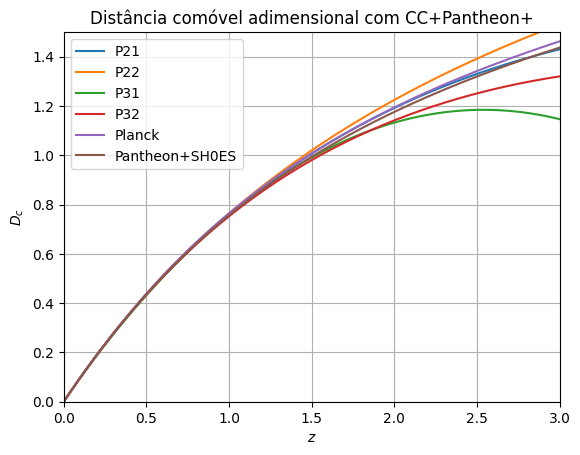

In [17]:
for i in modelos:
    plt.plot(z, values_PP[i]["Dc"], label=i)
plt.plot(z, DcLCDM(z,planck), label="Planck")
plt.plot(z, DcLCDM(z,sh0es), label="Pantheon+SH0ES")

plt.xlim(0, 3)
plt.ylim(0, 1.5)
plt.xlabel("$z$")
plt.ylabel("$D_{c}$")
plt.title("Distância comóvel adimensional com CC+Pantheon+")
plt.grid()
plt.legend()
plt.show()

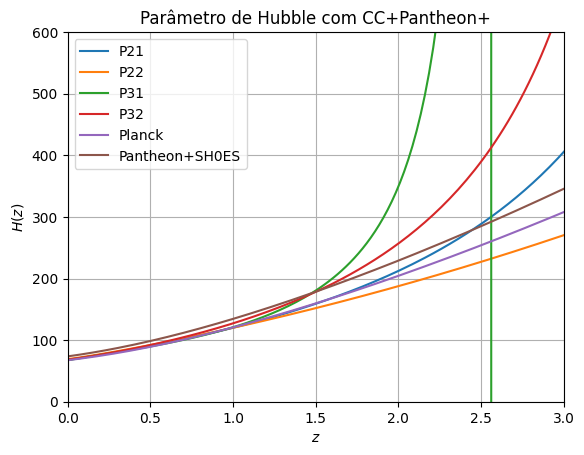

In [20]:
for i in modelos:
    plt.plot(z, values_PP[i]["Hz"], label=i)
plt.plot(z, HzLCDM(z, planck), label="Planck")
plt.plot(z, HzLCDM(z, sh0es), label="Pantheon+SH0ES")

plt.xlim(0, 3)
plt.ylim(0, 600)
plt.xlabel("$z$")
plt.ylabel("$H(z)$")
plt.title("Parâmetro de Hubble com CC+Pantheon+")
plt.grid()
plt.legend()
plt.show()

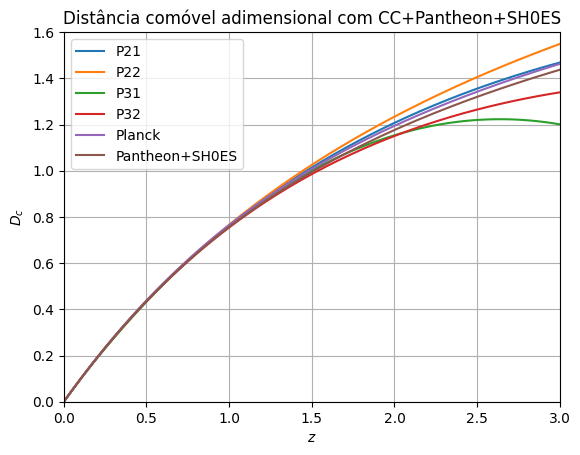

In [25]:
for i in modelos:
    plt.plot(z, values_PS[i]["Dc"], label=i)
plt.plot(z, DcLCDM(z,planck), label="Planck")
plt.plot(z, DcLCDM(z,sh0es), label="Pantheon+SH0ES")

plt.xlim(0, 3)
plt.ylim(0, 1.6)
plt.xlabel("$z$")
plt.ylabel("$D_{c}$")
plt.title("Distância comóvel adimensional com CC+Pantheon+SH0ES")
plt.grid()
plt.legend()
plt.show()

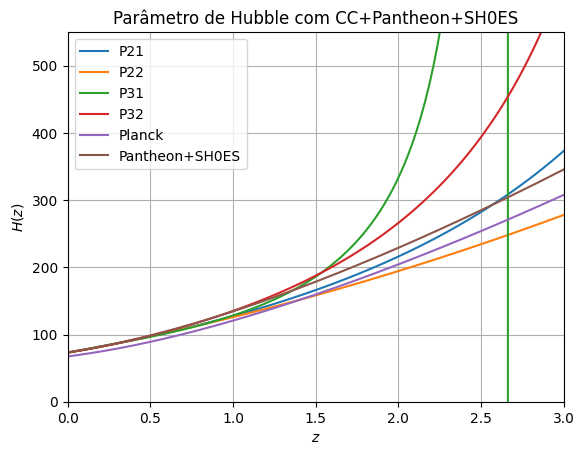

In [15]:
for i in modelos:
    plt.plot(z, values_PS[i]["Hz"], label=i)
plt.plot(z, HzLCDM(z, planck), label="Planck")
plt.plot(z, HzLCDM(z, sh0es), label="Pantheon+SH0ES")

plt.xlim(0, 3)
plt.ylim(0, 550)
plt.xlabel("$z$")
plt.ylabel("$H(z)$")
plt.title("Parâmetro de Hubble com CC+Pantheon+SH0ES")
plt.grid()
plt.legend()
plt.show()

In [16]:
print("Delta logZ (P21)")
print("CC+Pantheon+")
for i in modelos:
    deltaZ = results_PP[i]["logZ"] - results_PP["P21"]["logZ"]
    print(f"{i} = {deltaZ}")

print("\nCC+Pantheon+SH0ES")
for i in modelos:
    deltaZ = results_PS[i]["logZ"] - results_PS["P21"]["logZ"]
    print(f"{i} = {deltaZ}")

print("\n\nDelta BIC (P21)")
print("CC+Pantheon+")
for i in modelos:
    deltaBIC = results_PP[i]["BIC"] - results_PP["P21"]["BIC"]
    print(f"{i} = {deltaBIC}")

print("\nCC+Pantheon+SH0ES")
for i in modelos:
    deltaBIC = results_PS[i]["BIC"] - results_PS["P21"]["BIC"]
    print(f"{i} = {deltaBIC}")

Delta logZ (P21)
CC+Pantheon+
P21 = 0.0
P22 = 2.6124583207350724
P31 = -2.291099299093162
P32 = -0.4300279464735013

CC+Pantheon+SH0ES
P21 = 0.0
P22 = 3.2589379228165853
P31 = -1.857375459285663
P32 = 0.08138656148469181


Delta BIC (P21)
CC+Pantheon+
P21 = 0.0
P22 = 6.627515234675457
P31 = 6.393415234675331
P32 = 13.942730469350863

CC+Pantheon+SH0ES
P21 = 0.0
P22 = 3.68539191680793
P31 = 6.511991916808029
P32 = 14.10378383361558


In [82]:
print("-"*30)
print("CC+Pantheon+")
print("-"*30)
modelComparison(results_PP, "P21")

print("\n\n"+"-"*30)
print("CC+Pantheon+SH0ES")
print("-"*30)
modelComparison(results_PS, "P21")

------------------------------
CC+Pantheon+
------------------------------
Delta logZ (P21)
P21 = 0.0 (Referência)
P22 = 2.612 (Evidência moderada em favor de P22)
P31 = -2.291 (Evidência moderada em favor de P21)
P32 = -0.43 (Evidência fraca/Inconclusivo em favor de P21)

Delta BIC (P21)
P21 = 0.0 (Referência)
P22 = 6.628 (Evidência forte)
P31 = 6.393 (Evidência forte)
P32 = 13.943 (Evidência muito forte)


------------------------------
CC+Pantheon+SH0ES
------------------------------
Delta logZ (P21)
P21 = 0.0 (Referência)
P22 = 3.259 (Evidência forte em favor de P22)
P31 = -1.857 (Evidência moderada em favor de P21)
P32 = 0.081 (Evidência fraca/Inconclusivo em favor de P32)

Delta BIC (P21)
P21 = 0.0 (Referência)
P22 = 3.685 (Evidência moderada)
P31 = 6.512 (Evidência forte)
P32 = 14.104 (Evidência muito forte)
